<a href="https://colab.research.google.com/github/AmaraRao19/News_Topic_Classifier_Using_BERT/blob/main/News_Topic_Classifier_Using_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import os

print(os.listdir("/content"))

['.config', '.gradio', 'task1_eda.png', 'results', 'NewsTopicClassifierUsingBERT.ipynb', 'sample_data']


In [50]:
from google.colab import files

uploaded = files.upload()  # this opens a file selector

Saving NewsTopicClassifierUsingBERT.ipynb to NewsTopicClassifierUsingBERT.ipynb


In [52]:
import nbformat

# Path to your current notebook
notebook_path = "/content/NewsTopicClassifierUsingBERT.ipynb"

# Load the notebook
nb = nbformat.read(notebook_path, as_version=4)

# Remove problematic widgets metadata
if "widgets" in nb.metadata:
    nb.metadata.pop("widgets")

# Remove 'metadata.widgets' in each cell
for cell in nb.cells:
    if "widgets" in cell.metadata:
        cell.metadata.pop("widgets")

# Save a cleaned notebook
clean_path = "/content/NewsTopicClassifierUsingBERT_clean.ipynb"
nbformat.write(nb, clean_path)
print(f"✅ Clean notebook saved at {clean_path}")

✅ Clean notebook saved at /content/NewsTopicClassifierUsingBERT_clean.ipynb


In [53]:
import nbformat

# Notebook path
notebook_path = "/content/NewsTopicClassifierUsingBERT.ipynb"

# Load notebook
nb = nbformat.read(notebook_path, as_version=4)

# Function to recursively remove widgets metadata
def clean_widgets(cell):
    # Remove cell-level widgets
    if "widgets" in cell.metadata:
        cell.metadata.pop("widgets")
    # Remove widgets from outputs if present
    if "outputs" in cell:
        for output in cell.outputs:
            if "metadata" in output and "widgets" in output.metadata:
                output.metadata.pop("widgets")
    return cell

# Apply cleaning to all cells
nb.cells = [clean_widgets(cell) for cell in nb.cells]

# Remove top-level widgets metadata if exists
nb.metadata.pop("widgets", None)

# Optionally remove all outputs (recommended for GitHub)
for cell in nb.cells:
    if "outputs" in cell:
        cell["outputs"] = []
    if "execution_count" in cell:
        cell["execution_count"] = None

# Save cleaned notebook
clean_path = "/content/NewsTopicClassifierUsingBERT_clean.ipynb"
nbformat.write(nb, clean_path)
print(f"✅ Fully cleaned notebook saved at {clean_path}")

✅ Fully cleaned notebook saved at /content/NewsTopicClassifierUsingBERT_clean.ipynb


Install dependencies:

In [47]:
!pip install torch transformers datasets scikit-learn gradio matplotlib seaborn --quiet

#Install Libraries

In [8]:
!pip install transformers datasets scikit-learn gradio --quiet

#Import Libraries

In [9]:
import torch
import numpy as np

from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

from sklearn.metrics import accuracy_score, f1_score

#Load AG News Dataset (DIRECTLY)

In [10]:
dataset = load_dataset("ag_news")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

#Reduce Dataset Size

In [11]:
small_train = dataset["train"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

#Load Tokenizer

1️⃣ NLP using Transformers

In [12]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

#Tokenization Function

In [13]:
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

#Apply Tokenization

In [14]:
train_data = small_train.map(tokenize, batched=True)
test_data = small_test.map(tokenize, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

#Format for PyTorch

In [15]:
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

2️⃣ Transfer Learning & Fine-Tuning

#Load Model

In [16]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#Training Arguments

In [18]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_steps=50
)

3️⃣ Evaluation Metrics for Text Classification

#Metrics (ACCURACY + F1)

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

#Trainer

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

#Train Model

In [22]:
trainer.train()

Step,Training Loss
50,0.392333
100,0.359811
150,0.198654
200,0.340519
250,0.292121
300,0.346420
350,0.413302
400,0.390084
450,0.303953
500,0.286935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.33241326332092286, metrics={'train_runtime': 83.3096, 'train_samples_per_second': 24.007, 'train_steps_per_second': 6.002, 'total_flos': 131557890048000.0, 'train_loss': 0.33241326332092286, 'epoch': 1.0})

#Evaluate Model

In [25]:
trainer.evaluate()

{'eval_loss': 0.5489419102668762,
 'eval_model_preparation_time': 0.005,
 'eval_accuracy': 0.88,
 'eval_f1': 0.8806722159144533,
 'eval_runtime': 5.588,
 'eval_samples_per_second': 89.477,
 'eval_steps_per_second': 22.369}

#Label Mapping

In [26]:
labels = ["World", "Sports", "Business", "Sci/Tech"]

#Prediction Function

In [29]:
def predict(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)   # move model to device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {key: val.to(device) for key, val in inputs.items()}  # move inputs to same device

    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

    return labels[pred]

#Test Prediction

In [33]:
predict("There is a cricket match between pakistan and india")

'Sports'

4️⃣ Lightweight Model Deployment

#Deployment (Gradio)

In [34]:
import gradio as gr

interface = gr.Interface(
    fn=predict,
    inputs="text",
    outputs="text",
    title="News Topic Classifier"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f17975868a7217670d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Label Count + Boxplot/Bar Chart
This shows how many samples belong to each category

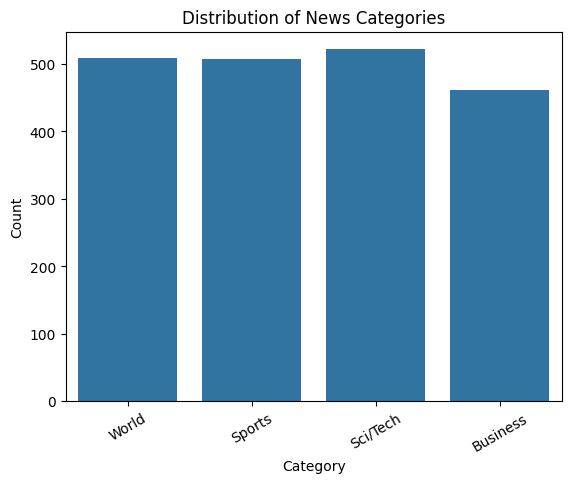

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert dataset to pandas
df = small_train.to_pandas()

# Label names
label_names = ["World", "Sports", "Business", "Sci/Tech"]

# Map numeric labels to names
df["label_name"] = df["label"].apply(lambda x: label_names[x])

# Count plot (BEST for classification)
plt.figure()
sns.countplot(x="label_name", data=df)
plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

#Boxplot

Shows how long news texts are in each category

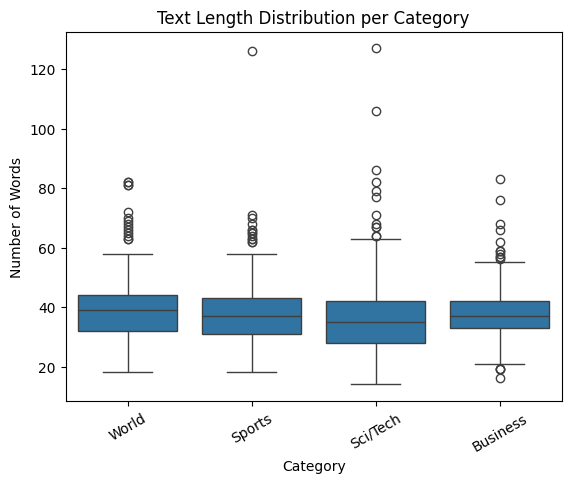

In [36]:
# Add text length column
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

plt.figure()
sns.boxplot(x="label_name", y="text_length", data=df)
plt.title("Text Length Distribution per Category")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.xticks(rotation=30)
plt.show()

#Histogram

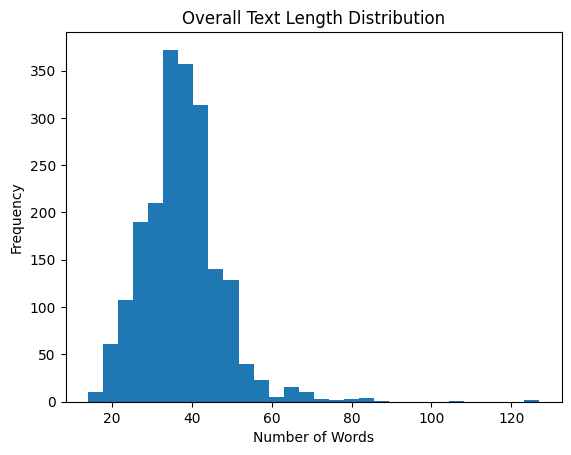

In [37]:
plt.figure()
plt.hist(df["text_length"], bins=30)
plt.title("Overall Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()